# Pitch Angle calculation

## Google Colab exclusive part starts here

The script below will automatically download the kernel data zip file from Google Drive, unpack it and download the magnetic field data created via `tsyganenko_geopack.ipynb` notebook.

In [1]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print("Detected Google Colab environment. Setting up workspace...")

    !pip install gdown
    import gdown

    file_url = "https://drive.google.com/file/d/1nxZexJNhfacVq16bF3LbKJ9P4MjbUNoK/view?usp=sharing"
    output_file = "magfield_data_2005.h5"

    # download magnetic field data
    gdown.download(file_url, output_file, quiet=False, fuzzy=True)

    file_url = "https://drive.google.com/file/d/138zsWVZaiMX1nhJEKV-u5_QJx_VLlarS/view?usp=drive_link"
    output_file = "kernels.tar.gz"

    # download kernels
    gdown.download(file_url, output_file, quiet=False, fuzzy=True)
    
    # unpack kernels
    !tar -xzf kernels.tar.gz

    # install required libraries
    !pip install geopack planetary-coverage spiceypy

else:
    print("Running in local environment. Skipping Colab-only setup.")

Running in local environment. Skipping Colab-only setup.


## Google Colab exclusive part ends here

---

## Notebook description

This notebook computes the cosine of pitch angle values between the orientation of IREM and the direction of magnetic vector modeled by Tsyganenko's model via the `02_tsyganenko_geopack.ipynb`. It then creates a HDF5 file containing both the magnetic field data and the pitch angle values.

#### REQUIRED INPUT:
 - INTEGRAL kernel data [`kernels.tar.gz`]
 - Magnetic field vector model data [`magfield_data_full.h5`]

#### OUTPUT:
 - An HDF5 file containing a table of modeled magnetic field vector components (XYZ), magnitude, geocentric distance and pitch angle cosine values for IREM [`irem_magnetic_pitch_angle_full.h5`]
 - Plots showcasing IREM's direction and the pitch angle cosine values for the selected time ranges. 

If you're getting a `ModuleNotFoundError` or any similiar one after running the below line of code - report to the person responsible for the notebook.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import spiceypy as spice


from planetary_coverage import TourConfig
from datetime import datetime, timedelta
from geopack import geopack

Load IGRF coefficients ...


Select the start and end date before loading the kernels. I reccomend selecting no more than 1 year at once, because it takes a few minutes to compute.

In [3]:
START_DATE = datetime(2005, 1, 1)
END_DATE = datetime(2005, 12, 31)


tour = TourConfig(
    spacecraft='INTEGRAL',
    target='EARTH',
    download_kernels=False,
    kernels_dir='./kernels',
    mk='ops',
    version='v001',
)

def build_irem_tour(target):
    return TourConfig(
        spacecraft='INTEGRAL',
        instrument='',
        target=target,
        download_kernels=False,
        kernels_dir='./kernels',
        mk='ops',
        version='v001',
    )

def build_irem_trajectory(tour: TourConfig, 
                          start_date: datetime = START_DATE, 
                          end_date: datetime = END_DATE, 
                          interval_time: timedelta = timedelta(minutes=5)):
                          
    interval = f'{interval_time.total_seconds() / 3600} hours'
    return tour[start_date: end_date: interval]

tour.load_kernels()

#Load custom GSE kernel
spice.furnsh("./kernels/fk/gse.tf")

Create and plot the xyz coordinates of IREM pointing direction - which is mounted pointing towards -z axis. The vector magnitude is also shown - mostly to make it clear that it's a normal vector.

,time,x,y,z
0,2005-01-01 00:00:00,-0.862657,-0.311840,-0.398219
1,2005-01-01 00:05:00,-0.862658,-0.311089,-0.398803
2,2005-01-01 00:10:00,-0.862660,-0.310303,-0.399412
3,2005-01-01 00:15:00,-0.862661,-0.309483,-0.400045
4,2005-01-01 00:20:00,-0.862732,-0.308542,-0.400618
5,2005-01-01 00:25:00,-0.862859,-0.307498,-0.401148
6,2005-01-01 00:30:00,-0.862985,-0.306422,-0.401699
7,2005-01-01 00:35:00,-0.863111,-0.305314,-0.402271
8,2005-01-01 00:40:00,-0.863237,-0.304174,-0.402864
9,2005-01-01 00:45:00,-0.863364,-0.303003,-0.403476


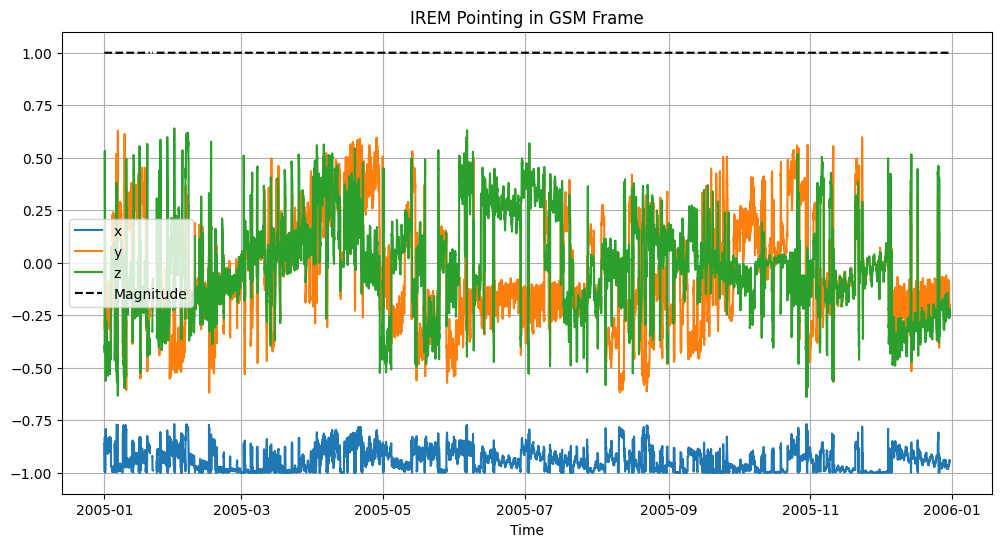

In [4]:
vec_sc = [0, 0, -1] #IREM is mounted on the spacecraft pointing towards -z axis of the spacecraft frame

from_frame = 'INTEGRAL_SPACECRAFT'
to_frame = 'GSE'


utc_times = pd.date_range(start=START_DATE, end=END_DATE, freq='5min')
xs, ys, zs = [], [], []

for utc_time in utc_times:
    try:
        et = spice.str2et(utc_time.isoformat())
        ps = geopack.recalc(et)
        rotation_matrix = spice.pxform(from_frame, to_frame, et)
        vec_inertial = spice.mxv(rotation_matrix, vec_sc)
        vec_inertial = geopack.gsmgse(vec_inertial[0], vec_inertial[1], vec_inertial[2], -1)
        xs.append(vec_inertial[0])
        ys.append(vec_inertial[1])
        zs.append(vec_inertial[2])
        
    except Exception as e:
        xs.append(np.nan)
        ys.append(np.nan)
        zs.append(np.nan)

# Create DataFrame with raw x, y, z coordinates in the target frame
df_gsm_direction = pd.DataFrame({
    'time': utc_times,
    'x': xs,
    'y': ys,
    'z': zs
})
df_gsm_direction.head()

magnitudes = np.sqrt(df_gsm_direction['x']**2 + df_gsm_direction['y']**2 + df_gsm_direction['z']**2)



#df[['x', 'y', 'z']] = df.apply(lambda row: pd.Series(geopack.gsmgse(row.x, row.y, row.z, -1)), axis=1) #-1 for GSE to GSM conversion

plt.figure(figsize=(12, 6))
plt.plot(df_gsm_direction['time'], df_gsm_direction['x'], label='x')
plt.plot(df_gsm_direction['time'], df_gsm_direction['y'], label='y')
plt.plot(df_gsm_direction['time'], df_gsm_direction['z'], label='z')
plt.plot(df_gsm_direction['time'], magnitudes, label='Magnitude', linestyle='--', color='black')
plt.xlabel('Time')
plt.title('IREM Pointing in GSM Frame')
plt.legend()
plt.grid(True)

df_gsm_direction.head(10)

Load the magnetic field vector data created using the `tsyganenko_geopack.ipynb` notebook. Download it and put it inside the main folder (not needed if using colab, already downloaded):

https://drive.google.com/file/d/1iy_CnmEd7WcP0txdR3y-wpBQGFnPxqhi/view?usp=sharing

In [5]:
loaded_df = pd.read_hdf('./magfield_data_full.h5', key="df", mode="r")

loaded_df.head()

,time,bx_gsm,by_gsm,bz_gsm,b_magnitude,r_distance
0,2002-10-17 05:45:00,-1.936223,1.995626,-31.222942,31.346508,1.130973
1,2002-10-17 05:50:00,5.366856,-3.565792,-29.003751,29.710867,1.118993
2,2002-10-17 05:55:00,9.396814,-1.985973,-28.377173,29.958440,1.198198
3,2002-10-17 06:00:00,8.892436,-1.964054,-28.993657,30.390213,1.351132
4,2002-10-17 06:05:00,9.060057,-4.413688,-30.588328,32.205762,1.551394


For convenience you can also manipulate the date down here. The pitch angle (between magnetic and IREM direction) is shown in degrees. Distance of INTEGRAL from Earth is also shown as a point of reference.

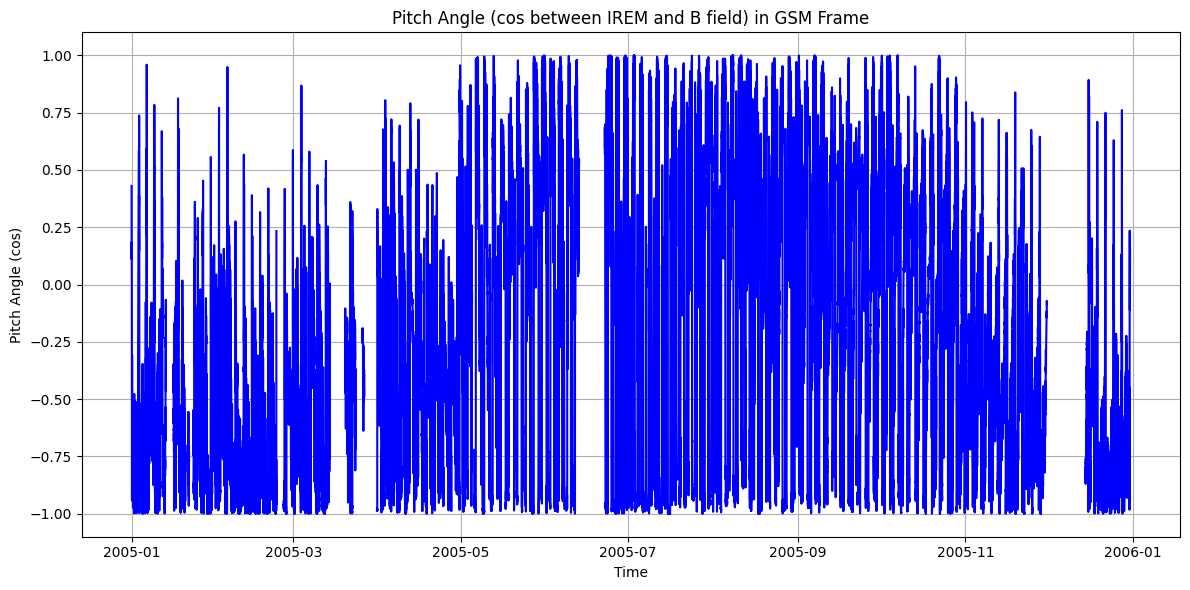

In [6]:
startdate = datetime(2002, 10, 17, 5, 45)  # When DF2 actually starts
enddate = datetime(2025, 2, 8, 16, 20)      # When DF2 actually ends

def angle_between(v1, v2):
    v1_u = v1 / np.linalg.norm(v1)
    v2_u = v2 / np.linalg.norm(v2)
    return np.clip(np.dot(v1_u, v2_u), -1.0, 1.0) # return cosine of the angle

subset_df = df_gsm_direction[(df_gsm_direction['time'] >= startdate) & (df_gsm_direction['time'] <= enddate)].copy()
subset_df2 = loaded_df[(loaded_df['time'] >= startdate) & (loaded_df['time'] <= enddate)].copy()

B_vec = np.array([subset_df2['bx_gsm'].values, subset_df2['by_gsm'].values, subset_df2['bz_gsm'].values]).T
d_vec = np.array([subset_df['x'].values, subset_df['y'].values, subset_df['z'].values]).T
subset_df['pitch_angle_cos'] = [angle_between(b, d) for b, d in zip(B_vec, d_vec)]
subset_df['pitch_angle_rad'] = np.arccos(subset_df['pitch_angle_cos'])


fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(subset_df['time'], subset_df['pitch_angle_cos'], label='Pitch Angle cos', color='blue')
ax1.set_xlabel('Time')
ax1.set_ylabel('Pitch Angle (cos)')
ax1.tick_params(axis='y')
ax1.set_title('Pitch Angle (cos between IREM and B field) in GSM Frame')
ax1.grid(True)

# ax2 = ax1.twinx()
# ax2.plot(subset_df2['time'], subset_df2['r_distance'], label='Distance to Earth', color='orange')
# ax2.set_ylabel('Distance to Earth (Re)')
# ax2.tick_params(axis='y')
# ax2.legend(loc='upper right')
plt.tight_layout()

plt.show()

In [ ]:
df_output = subset_df2.merge(subset_df, on='time', how='inner')
df_output = df_output.drop(columns=['x', 'y', 'z'])

#save as h5
df_output.to_hdf('irem_magnetic_pitch_angle_full.h5', key='df', mode='w')

In [31]:
df_output.head()

,time,bx_gsm,by_gsm,bz_gsm,b_magnitude,r_distance,pitch_angle_cos,pitch_angle_rad
0,2002-10-17 05:45:00,-1.936223,1.995626,-31.222942,31.346508,1.130973,NaN,NaN
1,2002-10-17 05:50:00,5.366856,-3.565792,-29.003751,29.710867,1.118993,-0.182694,1.754522
2,2002-10-17 05:55:00,9.396814,-1.985973,-28.377173,29.958440,1.198198,-0.315847,1.892146
3,2002-10-17 06:00:00,8.892436,-1.964054,-28.993657,30.390213,1.351132,-0.294741,1.869981
4,2002-10-17 06:05:00,9.060057,-4.413688,-30.588328,32.205762,1.551394,-0.282981,1.857697
